## 0. Configuracao do Ambiente

A celula abaixo instala dependencias ausentes quando necessario. Em ambientes ja preparados, ela apenas importa as bibliotecas.

In [1]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.stats import mannwhitneyu

from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
try:
    import xgboost as xgb
except ImportError:
    xgb = None

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

PROJECT_DIR = Path.cwd()
PROJECT_ROOT_FALLBACK = Path("/home/jota/digital_college/py03/PY03_EngenhariaDeIA/aula18/atividade_Aula/life_expectancy_project")
DATA_CANDIDATES = [
    PROJECT_DIR / "data" / "expectativa_vida_2016_2025.csv",
    PROJECT_DIR / "expectativa_vida_2016_2025.csv",
    PROJECT_ROOT_FALLBACK / "data" / "expectativa_vida_2016_2025.csv",
    PROJECT_ROOT_FALLBACK / "expectativa_vida_2016_2025.csv",
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError("Dataset expectativa_vida_2016_2025.csv nao encontrado.")

PROJECT_DIR = DATA_PATH.parent.parent if DATA_PATH.parent.name == "data" else DATA_PATH.parent

print("Projeto:", PROJECT_DIR)
print("Dataset:", DATA_PATH)

Projeto: /home/jota/digital_college/py03/PY03_EngenhariaDeIA/aula18/atividade_Aula/life_expectancy_project
Dataset: /home/jota/digital_college/py03/PY03_EngenhariaDeIA/aula18/atividade_Aula/life_expectancy_project/data/expectativa_vida_2016_2025.csv


## 1. Analise Exploratoria de Dados (EDA)

Nesta etapa, olhamos o dataset bruto para identificar estrutura, tipos, valores ausentes, distribuicao da variavel-alvo e sinais de problemas de qualidade.

In [3]:
df_raw = pd.read_csv(DATA_PATH)

print("Shape:", df_raw.shape)
print("\nTipos de dados:")
display(df_raw.dtypes.to_frame("dtype"))

Shape: (1945, 22)

Tipos de dados:


,dtype
Country,str
Year,str
Status,str
Life expectancy,str
Adult Mortality,int64
infant deaths,int64
Alcohol,str
percentage expenditure,float64
Hepatitis B,float64
Measles,int64


In [4]:
print("\nPrimeiras linhas:")
display(df_raw.head())


Primeiras linhas:


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2016,Developing,65.04,260,61,0.07,91.140,64.040,1155,19.12,82,6.410,8.21,66.530,0.100,765.23,34225634,16.980,17.200,0.41,10.03
1,Afghanistan,2017,Developing,66.98,259,61,0.04,113.060,66.540,1146,19.33,83,6.920,8.05,65.840,0.060,931.11,34832494,16.690,17.370,0.44,9.93
2,Afghanistan,2018,Developing,68.02,253,60,0.05,133.260,67.860,1152,19.53,84,7.370,8,65.530,0.010,1118.09,35204149,16.980,17.180,0.42,9.95
3,Afghanistan,2019,Developing,68.12,248,58,0.17,151.630,67.360,1133,19.12,83,7.690,8.12,66.100,0.000,1309.56,35817726,17.080,16.970,0.4,9.91
4,Afghanistan,2020,Developing,69.27,244,57,0.23,169.990,67.560,1097,18.91,82,8.140,8.28,66.480,0.000,1492.86,36143541,16.720,16.600,0.39,10.01


In [5]:
print("\nResumo estatistico bruto:")
display(df_raw.describe(include="all").T)


Resumo estatistico bruto:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,1945,233,Cuba,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,1945,37,2024,193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,1945,8,Developing,1579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Life expectancy,1937,1405,90,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Adult Mortality,"1,945.000",NaN,NaN,NaN,142.386,103.191,-5.000,64.000,130.000,195.000,"1,200.000"
infant deaths,"1,945.000",NaN,NaN,NaN,21.100,81.811,0.000,0.000,0.000,12.000,948.000
Alcohol,1924,657,0,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN
percentage expenditure,"1,945.000",NaN,NaN,NaN,119.254,91.880,19.870,60.180,117.920,162.150,"1,095.990"
Hepatitis B,"1,935.000",NaN,NaN,NaN,84.289,23.626,6.530,83.540,94.570,98.280,99.000
Measles,"1,945.000",NaN,NaN,NaN,"1,412.140","7,664.933",0.000,0.000,0.000,149.000,"92,356.000"


In [6]:
missing_report = (
    df_raw.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda data: 100 * data["missing_count"] / len(df_raw))
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)

display(missing_report)
print("Colunas com mais de 10% de ausentes:")
display(missing_report.query("missing_pct > 10"))

,missing_count,missing_pct
GDP,22,1.131
Income composition of resources,21,1.080
Alcohol,21,1.080
Schooling,12,0.617
Total expenditure,12,0.617
Hepatitis B,10,0.514
Population,9,0.463
Life expectancy,8,0.411
BMI,6,0.308


Colunas com mais de 10% de ausentes:


,missing_count,missing_pct


### 1.1 Funcao auxiliar para leitura numerica

/tmp/ipykernel_216789/3611848351.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x="status_clean", y="life_expectancy_num", ax=axes[1], palette="Set2")


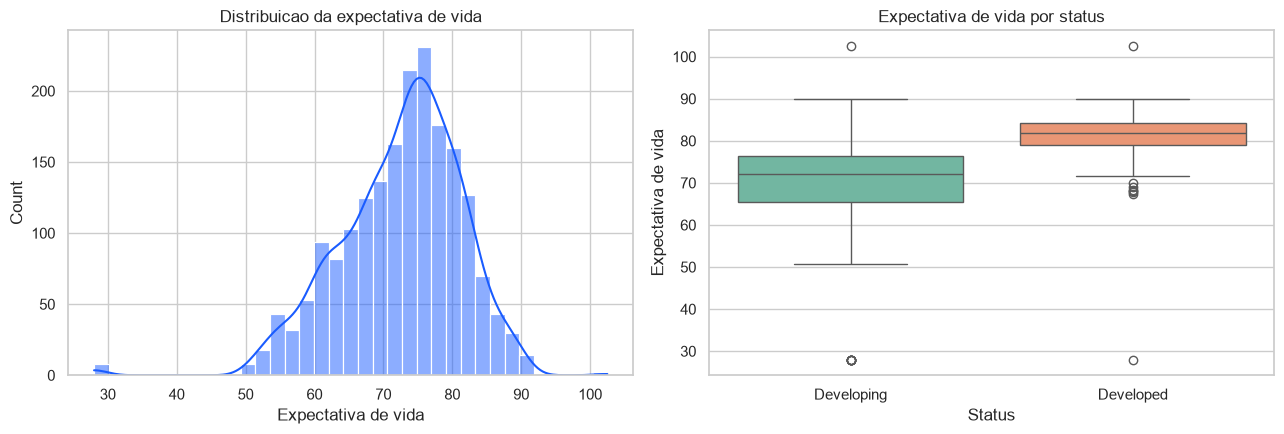

In [7]:
def fix_numeric(series: pd.Series) -> pd.Series:
    """Converte series potencialmente numericas com virgula decimal ou separador de milhar."""
    cleaned = series.astype("string").str.strip()
    cleaned = cleaned.str.replace(r"(?<=\d),(?=\d{3}(?:[,\s]|$))", "", regex=True)
    cleaned = cleaned.str.replace(",", ".", regex=False)
    cleaned = cleaned.replace({"": np.nan, "nan": np.nan, "None": np.nan, "<NA>": np.nan})
    return pd.to_numeric(cleaned, errors="coerce")

eda_df = df_raw.copy()
eda_df["life_expectancy_num"] = fix_numeric(eda_df["Life expectancy "])
eda_df["status_clean"] = eda_df["Status"].astype("string").str.strip().str.title()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(eda_df["life_expectancy_num"], bins=35, kde=True, color="#1A5CFF", ax=axes[0])
axes[0].set_title("Distribuicao da expectativa de vida")
axes[0].set_xlabel("Expectativa de vida")

sns.boxplot(data=eda_df, x="status_clean", y="life_expectancy_num", ax=axes[1], palette="Set2")
axes[1].set_title("Expectativa de vida por status")
axes[1].set_xlabel("Status")
axes[1].set_ylabel("Expectativa de vida")

plt.tight_layout()
plt.show()

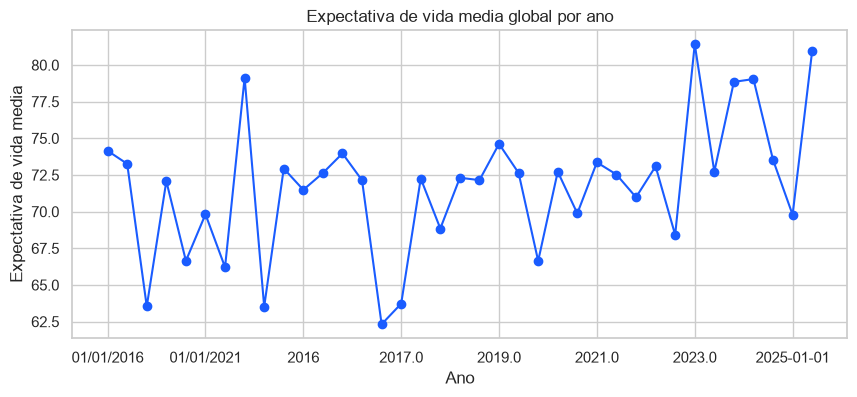

In [8]:
trend = eda_df.groupby("Year", as_index=True)["life_expectancy_num"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
trend.plot(marker="o", color="#1A5CFF", ax=ax)
ax.set_title("Expectativa de vida media global por ano")
ax.set_ylabel("Expectativa de vida media")
ax.set_xlabel("Ano")
plt.show()

### 1.2 Perguntas orientadoras da EDA

**Q1 - Qual a distribuicao da variavel-alvo?**  
A expectativa de vida tem skewness de aproximadamente `-0.762`, indicando distribuicao **assimetrica a esquerda**. Isso significa que ha concentracao maior em valores altos de expectativa de vida e uma cauda mais longa em valores baixos.

**Q2 - Quanto de dados ausentes existem? Quais colunas tem mais de 10% de missings?**  
Nenhuma coluna ultrapassa `10%` de valores ausentes no dataset bruto. Ainda assim, ha ausencias pontuais em variaveis como `GDP`, `Income composition of resources`, `Alcohol`, `Schooling`, `Total expenditure`, `Hepatitis B`, `Population`, `Life expectancy` e `BMI`, que serao tratadas no Data Munging.

**Q3 - Paises em desenvolvimento vs. desenvolvidos diferem significativamente?**  
Sim. O teste de Mann-Whitney retorna `p-value = 2.858e-114`, muito abaixo de `0.05`, indicando diferenca estatisticamente significativa entre os grupos `Developed` e `Developing`.

**Q4 - Quais variaveis tem alta skewness? Como tratar GDP, Population e Measles?**  
As maiores assimetrias aparecem em `GDP`, `Measles`, `infant deaths`, `under-five deaths`, `Population`, `percentage expenditure`, `HIV/AIDS`, `Diphtheria`, `Polio` e `Adult Mortality`. Para `GDP`, `Population`, `Measles` e `percentage expenditure`, a estrategia adotada na engenharia de recursos e aplicar `log1p`, reduzindo a influencia de valores extremos.

In [9]:
target_skew = eda_df["life_expectancy_num"].skew()
if abs(target_skew) < 0.5:
    target_shape = "aproximadamente simetrica"
elif target_skew > 0:
    target_shape = "assimetrica a direita"
else:
    target_shape = "assimetrica a esquerda"

missing_over_10 = missing_report.query("missing_pct > 10")

status_target = eda_df.dropna(subset=["life_expectancy_num"])
developed = status_target.loc[status_target["status_clean"] == "Developed", "life_expectancy_num"]
developing = status_target.loc[status_target["status_clean"] == "Developing", "life_expectancy_num"]
statistic, p_value = mannwhitneyu(developed, developing, alternative="two-sided")

numeric_like_cols = [col for col in df_raw.columns if col not in ["Country", "Status"]]
numeric_eda = df_raw[numeric_like_cols].apply(fix_numeric)
skewness = numeric_eda.skew(numeric_only=True).sort_values(key=lambda values: values.abs(), ascending=False)

eda_metrics = pd.DataFrame([
    {"metrica": "target_skew", "valor": target_skew},
    {"metrica": "colunas_missing_gt_10pct", "valor": len(missing_over_10)},
    {"metrica": "mannwhitney_statistic", "valor": statistic},
    {"metrica": "mannwhitney_p_value", "valor": p_value},
])

display(eda_metrics)
display(skewness.head(10).to_frame("skewness"))

,metrica,valor
0,target_skew,-0.762
1,colunas_missing_gt_10pct,0.000
2,mannwhitney_statistic,"465,579.000"
3,mannwhitney_p_value,0.000


,skewness
GDP,26.420
Measles,9.218
infant deaths,8.210
under-five deaths,7.820
Population,7.145
percentage expenditure,4.801
HIV/AIDS,3.541
Diphtheria,-2.385
Polio,-2.221
Adult Mortality,2.214


In [10]:
quality_findings = {
    "status_values_raw": df_raw["Status"].value_counts(dropna=False).to_dict(),
    "country_with_outer_spaces": int(df_raw["Country"].astype("string").str.match(r"^\s|\s$").sum()),
    "adult_mortality_negative": int((fix_numeric(df_raw["Adult Mortality"]) < 0).sum()),
    "life_expectancy_as_object": str(df_raw["Life expectancy "].dtype),
    "gdp_as_object": str(df_raw["GDP"].dtype),
    "population_as_object": str(df_raw[" Population"].dtype),
}

print("Achados de qualidade identificados na EDA:")
for key, value in quality_findings.items():
    print(f"- {key}: {value}")

Achados de qualidade identificados na EDA:
- status_values_raw: {'Developing': 1579, 'Developed': 316, ' Developing ': 18, 'DEVELOPING': 18, 'developing': 9, 'DEVELOPED': 3, ' Developed ': 1, 'developed': 1}
- country_with_outer_spaces: 50
- adult_mortality_negative: 4
- life_expectancy_as_object: str
- gdp_as_object: str
- population_as_object: str


## 2. Data Munging

Objetivo da etapa: produzir um dataframe limpo, sem valores ausentes, com `Status` em apenas duas categorias e campos numericos com tipo adequado. Ao final, salvamos `df_clean.csv`.

In [11]:
def normalize_column_name(column: str) -> str:
    normalized = unicodedata.normalize("NFKD", column).encode("ascii", "ignore").decode("ascii")
    normalized = normalized.strip().lower()
    normalized = re.sub(r"\s+", "_", normalized)
    normalized = re.sub(r"[^a-z0-9_]", "", normalized)
    normalized = re.sub(r"_+", "_", normalized).strip("_")
    return normalized


def impute_by_group(data: pd.DataFrame, column: str, group_columns: list[str]) -> pd.DataFrame:
    data[column] = data.groupby(group_columns, dropna=False)[column].transform(lambda values: values.fillna(values.median()))
    return data


df_clean = df_raw.copy()
df_clean.columns = [normalize_column_name(col) for col in df_clean.columns]

# Strings de identificacao/categoria.
df_clean["country"] = df_clean["country"].astype("string").str.strip()
df_clean["status"] = df_clean["status"].astype("string").str.strip().str.title()
df_clean.loc[~df_clean["status"].isin(["Developing", "Developed"]), "status"] = pd.NA
df_clean["status"] = df_clean["status"].fillna(df_clean["status"].mode().iloc[0])

# Conversao numerica robusta.
non_numeric_cols = ["country", "status"]
for col in [col for col in df_clean.columns if col not in non_numeric_cols]:
    df_clean[col] = fix_numeric(df_clean[col])

# Remocao de duplicatas exatas, se existirem.
duplicate_count = int(df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# Valores impossiveis ou implausiveis viram NaN para posterior imputacao.
non_negative_cols = [
    "life_expectancy",
    "adult_mortality",
    "infant_deaths",
    "alcohol",
    "percentage_expenditure",
    "measles",
    "bmi",
    "underfive_deaths",
    "total_expenditure",
    "hivaids",
    "gdp",
    "population",
    "thinness_119_years",
    "thinness_59_years",
    "schooling",
]
for col in non_negative_cols:
    if col in df_clean.columns:
        df_clean.loc[df_clean[col] < 0, col] = np.nan

bounded_cols = {
    "life_expectancy": (35, 100),
    "hepatitis_b": (0, 100),
    "polio": (0, 100),
    "diphtheria": (0, 100),
    "income_composition_of_resources": (0, 1),
    "bmi": (5, 80),
    "year": (2016, 2025),
}
for col, (lower, upper) in bounded_cols.items():
    if col in df_clean.columns:
        df_clean.loc[~df_clean[col].between(lower, upper), col] = np.nan

missing_before_imputation = df_clean.isna().sum().sort_values(ascending=False)

# Imputacao: mediana do pais, fallback por status, fallback global.
numeric_cols = df_clean.select_dtypes(include="number").columns.tolist()
for col in numeric_cols:
    df_clean = impute_by_group(df_clean, col, ["country"])
    df_clean = impute_by_group(df_clean, col, ["status"])
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Ajuste de tipos inteiros apos imputacao.
integer_cols = ["year", "adult_mortality", "infant_deaths", "measles", "underfive_deaths"]
for col in integer_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].round().astype(int)

remaining_missing = int(df_clean.isna().sum().sum())
status_counts = df_clean["status"].value_counts()

clean_path = PROJECT_DIR / "data" / "df_clean.csv"
clean_path.parent.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(clean_path, index=False)

print(f"Duplicatas exatas removidas: {duplicate_count}")
print(f"Missings restantes: {remaining_missing}")
print("Categorias em status:")
display(status_counts.to_frame("count"))
print("Tipos apos limpeza:")
display(df_clean.dtypes.to_frame("dtype"))
print("Arquivo salvo em:", clean_path)

print("\nColunas com ausentes antes da imputacao:")
display(missing_before_imputation[missing_before_imputation > 0].to_frame("missing_before_imputation"))

Duplicatas exatas removidas: 15
Missings restantes: 0
Categorias em status:


,count
status,
Developing,1610
Developed,320


Tipos apos limpeza:


,dtype
country,string
year,int64
status,string
life_expectancy,Float64
adult_mortality,int64
infant_deaths,int64
alcohol,Float64
percentage_expenditure,Float64
hepatitis_b,Float64
measles,int64


Arquivo salvo em: /home/jota/digital_college/py03/PY03_EngenhariaDeIA/aula18/atividade_Aula/life_expectancy_project/data/df_clean.csv

Colunas com ausentes antes da imputacao:


,missing_before_imputation
gdp,55
year,24
alcohol,21
income_composition_of_resources,21
life_expectancy,21
total_expenditure,12
schooling,12
population,10
hepatitis_b,10
bmi,8


## 3. Engenharia de Recursos

Criamos variaveis para reduzir assimetria, consolidar indicadores correlacionados e representar status e tendencia temporal.

Observacao importante: `mortality_le_ratio` e criado como feature exploratoria porque foi solicitado no case, mas ele usa a propria variavel-alvo no denominador. Por isso, fica fora da matriz final de modelagem para evitar vazamento de informacao.

In [12]:
df_feat = df_clean.copy()

log_cols = ["gdp", "population", "measles", "percentage_expenditure"]
for col in log_cols:
    df_feat[f"log_{col}"] = np.log1p(df_feat[col].clip(lower=0))

df_feat["vaccine_coverage_avg"] = df_feat[["hepatitis_b", "polio", "diphtheria"]].mean(axis=1)
df_feat["disease_burden"] = df_feat["hivaids"] + df_feat["measles"]
df_feat["thinness_avg"] = df_feat[["thinness_119_years", "thinness_59_years"]].mean(axis=1)
df_feat["mortality_le_ratio"] = df_feat["adult_mortality"] / df_feat["life_expectancy"].replace(0, np.nan)
df_feat["status_enc"] = (df_feat["status"] == "Developed").astype(int)
df_feat["year_norm"] = (df_feat["year"] - 2016) / 9

candidate_features = [
    "adult_mortality",
    "infant_deaths",
    "alcohol",
    "log_percentage_expenditure",
    "vaccine_coverage_avg",
    "log_measles",
    "bmi",
    "underfive_deaths",
    "total_expenditure",
    "hivaids",
    "log_gdp",
    "log_population",
    "income_composition_of_resources",
    "schooling",
    "thinness_avg",
    "disease_burden",
    "status_enc",
    "year_norm",
]

selected_features = [
    "adult_mortality",
    "log_gdp",
    "schooling",
    "income_composition_of_resources",
    "vaccine_coverage_avg",
    "hivaids",
    "thinness_avg",
    "status_enc",
    "year_norm",
    "total_expenditure",
    "bmi",
]

target_col = "life_expectancy"

feature_preview = df_feat[[target_col] + selected_features + ["mortality_le_ratio"]].head()
print("Features selecionadas para modelagem:")
print(selected_features)
display(feature_preview)

Features selecionadas para modelagem:
['adult_mortality', 'log_gdp', 'schooling', 'income_composition_of_resources', 'vaccine_coverage_avg', 'hivaids', 'thinness_avg', 'status_enc', 'year_norm', 'total_expenditure', 'bmi']


,life_expectancy,adult_mortality,log_gdp,schooling,income_composition_of_resources,vaccine_coverage_avg,hivaids,thinness_avg,status_enc,year_norm,total_expenditure,bmi,mortality_le_ratio
0,65.040,260,6.641,10.030,0.410,45.660,0.100,17.090,0,0.000,8.210,19.120,3.998
1,66.980,259,6.837,9.930,0.440,46.433,0.060,17.030,0,0.111,8.050,19.330,3.867
2,68.020,253,7.020,9.950,0.420,46.920,0.010,17.080,0,0.222,8.000,19.530,3.719
3,68.120,248,7.178,9.910,0.400,47.050,0.000,17.025,0,0.333,8.120,19.120,3.641
4,69.270,244,7.309,10.010,0.390,47.393,0.000,16.660,0,0.444,8.280,18.910,3.522


## 4. Correlacao e Multicolinearidade

Vamos medir associacoes com a variavel-alvo e verificar inflacao de variancia (VIF). Como o VIF e sensivel a variaveis redundantes, usamos a lista selecionada, que ja consolida vacinas e magreza.

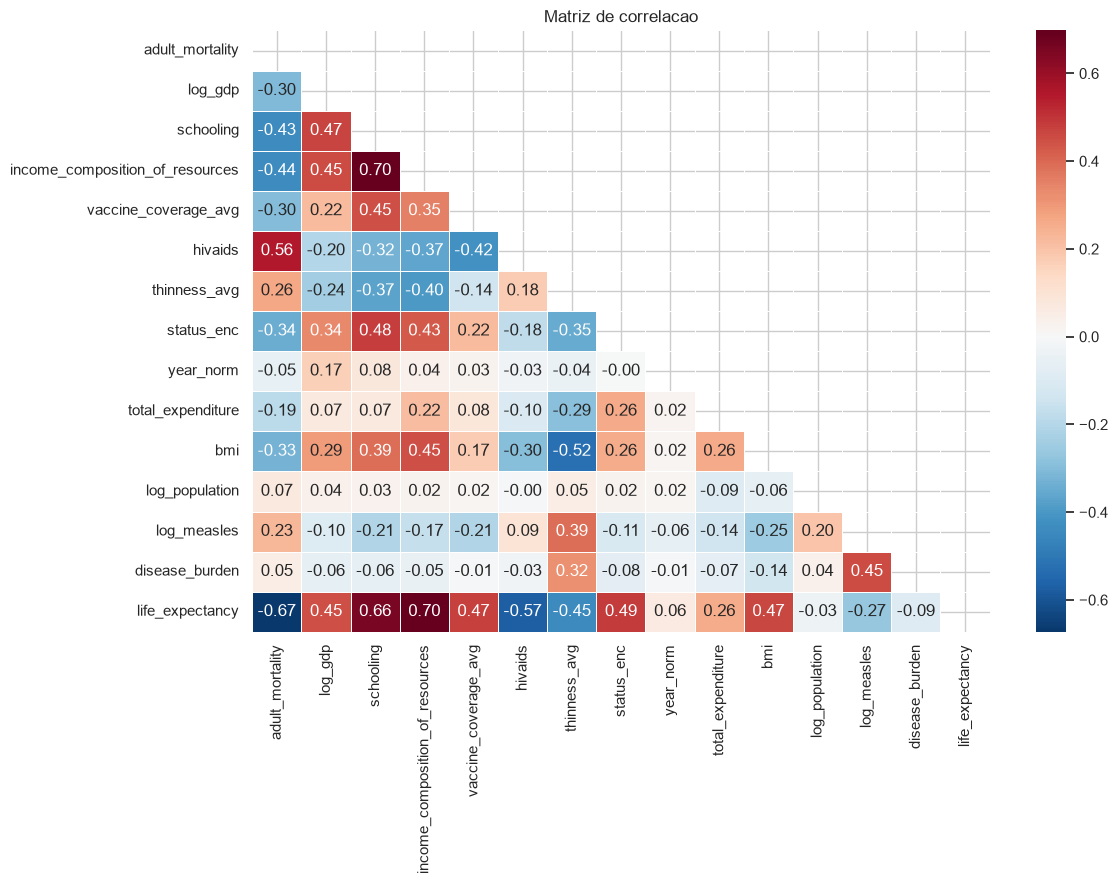

Top correlacoes absolutas com expectativa de vida:


,correlation
income_composition_of_resources,0.698
adult_mortality,-0.673
schooling,0.659
hivaids,-0.574
status_enc,0.489
vaccine_coverage_avg,0.473
bmi,0.467
log_gdp,0.448
thinness_avg,-0.446
log_measles,-0.270


In [13]:
corr_features = selected_features + ["log_population", "log_measles", "disease_burden"]
corr_features = list(dict.fromkeys(corr_features))

corr = df_feat[corr_features + [target_col]].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Matriz de correlacao")
plt.tight_layout()
plt.show()

target_corr = corr[target_col].drop(target_col).sort_values(key=lambda values: values.abs(), ascending=False)
print("Top correlacoes absolutas com expectativa de vida:")
display(target_corr.head(10).to_frame("correlation"))

In [14]:
def calculate_vif(data: pd.DataFrame) -> pd.DataFrame:
    scaled = pd.DataFrame(
        StandardScaler().fit_transform(data),
        columns=data.columns,
        index=data.index,
    )
    x_vif = sm.add_constant(scaled)
    vif_data = pd.DataFrame({
        "feature": x_vif.columns,
        "VIF": [variance_inflation_factor(x_vif.values, i) for i in range(x_vif.shape[1])],
    })
    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

vif_table = calculate_vif(df_feat[selected_features])
print("VIF das features selecionadas:")
display(vif_table)
print("Regra pratica: VIF > 10 indica alta multicolinearidade a investigar.")

VIF das features selecionadas:


,feature,VIF
0,schooling,2.581
1,income_composition_of_resources,2.318
2,adult_mortality,1.723
3,hivaids,1.670
4,bmi,1.610
5,thinness_avg,1.554
6,status_enc,1.491
7,vaccine_coverage_avg,1.417
8,log_gdp,1.412
9,total_expenditure,1.218


Regra pratica: VIF > 10 indica alta multicolinearidade a investigar.


## 5. Modelagem Estatistica com OLS

O modelo OLS fornece interpretabilidade: coeficientes, significancia estatistica, R2 ajustado, diagnosticos de residuos, Durbin-Watson, Jarque-Bera e numero de condicao.

In [15]:
X_ols_scaled = pd.DataFrame(
    StandardScaler().fit_transform(df_feat[selected_features]),
    columns=selected_features,
    index=df_feat.index,
)
y = df_feat[target_col]

X_ols_const = sm.add_constant(X_ols_scaled)
ols_model = sm.OLS(y, X_ols_const).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     511.5
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:03:43   Log-Likelihood:                -5496.3
No. Observations:                1930   AIC:                         1.102e+04
Df Residuals:                    1918   BIC:                         1.108e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

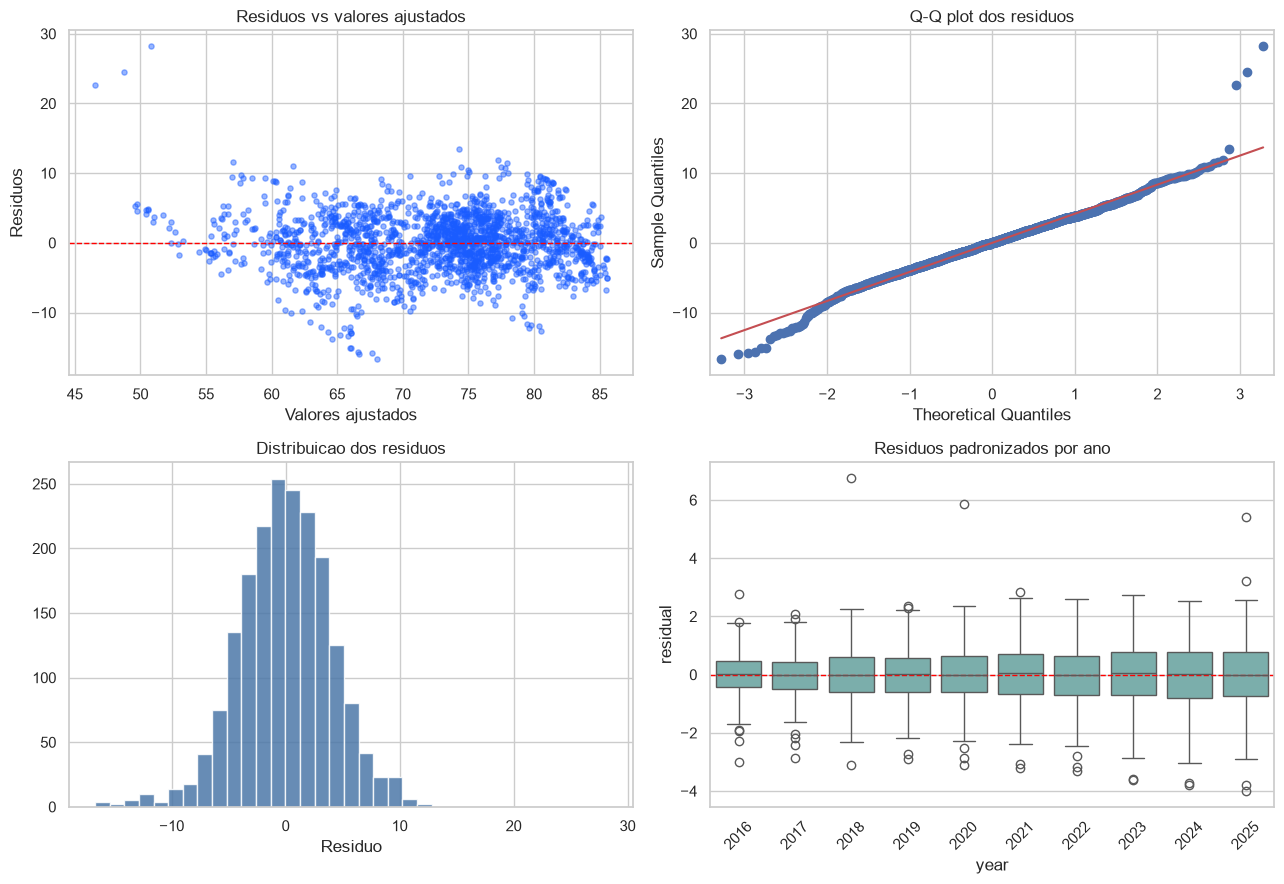

In [16]:
residuals = ols_model.resid
fitted = ols_model.fittedvalues
standardized_residuals = (residuals - residuals.mean()) / residuals.std()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].scatter(fitted, residuals, alpha=0.45, s=14, color="#1A5CFF")
axes[0, 0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0, 0].set_title("Residuos vs valores ajustados")
axes[0, 0].set_xlabel("Valores ajustados")
axes[0, 0].set_ylabel("Residuos")

sm.qqplot(residuals, line="s", ax=axes[0, 1])
axes[0, 1].set_title("Q-Q plot dos residuos")

axes[1, 0].hist(residuals, bins=35, color="#4C78A8", alpha=0.85)
axes[1, 0].set_title("Distribuicao dos residuos")
axes[1, 0].set_xlabel("Residuo")

sns.boxplot(data=pd.DataFrame({"year": df_feat["year"], "residual": standardized_residuals}), x="year", y="residual", ax=axes[1, 1], color="#72B7B2")
axes[1, 1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1, 1].set_title("Residuos padronizados por ano")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [17]:
ols_benchmarks = pd.DataFrame([
    {"indicador": "R2", "valor": ols_model.rsquared, "benchmark": "> 0.85", "ok": ols_model.rsquared > 0.85},
    {"indicador": "Adj. R2", "valor": ols_model.rsquared_adj, "benchmark": "> 0.83", "ok": ols_model.rsquared_adj > 0.83},
    {"indicador": "p-value F", "valor": ols_model.f_pvalue, "benchmark": "< 0.05", "ok": ols_model.f_pvalue < 0.05},
    {"indicador": "Durbin-Watson", "valor": sm.stats.stattools.durbin_watson(ols_model.resid), "benchmark": "~ 2.0", "ok": 1.5 <= sm.stats.stattools.durbin_watson(ols_model.resid) <= 2.5},
    {"indicador": "Cond. No.", "valor": ols_model.condition_number, "benchmark": "< 30", "ok": ols_model.condition_number < 30},
])

display(ols_benchmarks)

,indicador,valor,benchmark,ok
0,R2,0.746,> 0.85,False
1,Adj. R2,0.744,> 0.83,False
2,p-value F,0.000,< 0.05,True
3,Durbin-Watson,0.374,~ 2.0,False
4,Cond. No.,3.927,< 30,True


## 6. Modelagem Preditiva

Treinamos e comparamos modelos lineares e de arvore. Para modelos lineares, o escalonamento e feito dentro de `Pipeline`, evitando vazamento do conjunto de teste.

In [18]:
X = df_feat[selected_features].copy()
y = df_feat[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge (alpha=1)": Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))]),
    "Lasso (alpha=0.1)": Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=0.1, max_iter=20000))]),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
}

if xgb is not None:
    models["XGBoost"] = xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )
else:
    print("XGBoost nao esta disponivel; comparacao seguira sem esse modelo.")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
records = []
fitted_models = {}
predictions = {}

for name, model in models.items():
    cv_r2 = cross_val_score(model, X_train, y_train, cv=kf, scoring="r2", n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    records.append({
        "model": name,
        "cv_r2_mean": cv_r2.mean(),
        "cv_r2_std": cv_r2.std(),
        "test_r2": r2_score(y_test, y_pred),
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
        "test_mae": mean_absolute_error(y_test, y_pred),
        "test_mape_pct": np.mean(np.abs((y_test - y_pred) / y_test)) * 100,
    })
    fitted_models[name] = model
    predictions[name] = y_pred

results_df = pd.DataFrame(records).sort_values("test_rmse").reset_index(drop=True)
best_model_name = results_df.loc[0, "model"]
best_model = fitted_models[best_model_name]
best_y_pred = predictions[best_model_name]

print("Ranking de modelos por RMSE no teste:")
display(results_df)
print(f"Melhor modelo selecionado: {best_model_name}")

Ranking de modelos por RMSE no teste:


,model,cv_r2_mean,cv_r2_std,test_r2,test_rmse,test_mae,test_mape_pct
0,Random Forest,0.950,0.008,0.963,1.628,1.104,1.523
1,Gradient Boosting,0.932,0.008,0.942,2.050,1.544,2.131
2,XGBoost,0.917,0.005,0.925,2.320,1.755,2.418
3,Linear Regression,0.734,0.020,0.754,4.213,3.287,4.603
4,Ridge (alpha=1),0.734,0.020,0.754,4.213,3.287,4.603
5,Lasso (alpha=0.1),0.734,0.020,0.754,4.214,3.278,4.588


Melhor modelo selecionado: Random Forest


### 6.1 Importancia de Variaveis

Para modelos de arvore, usamos `feature_importances_`. Para modelos lineares, usamos coeficientes absolutos. Caso o estimador nao exponha nenhum dos dois, usamos importancia por permutacao.

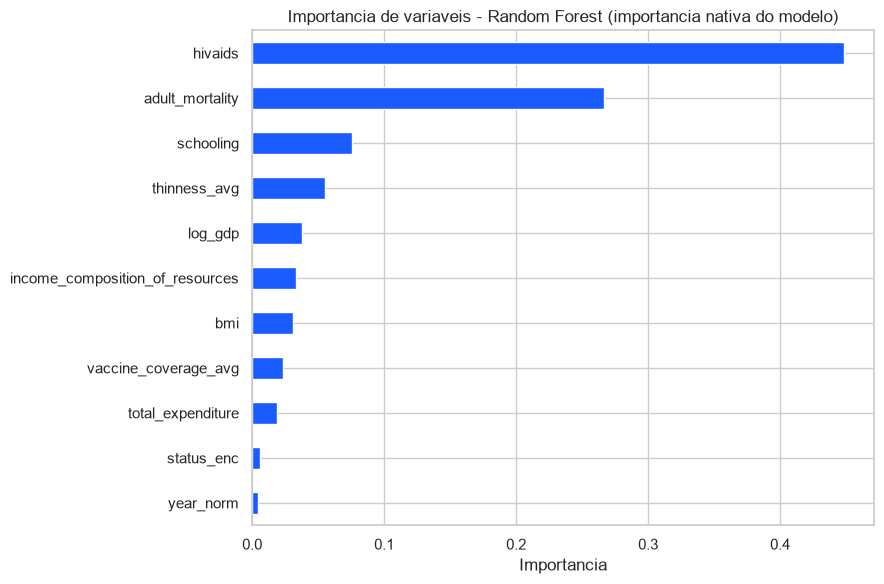

,importance
hivaids,0.449
adult_mortality,0.267
schooling,0.076
thinness_avg,0.055
log_gdp,0.038
income_composition_of_resources,0.033
bmi,0.031
vaccine_coverage_avg,0.023
total_expenditure,0.019
status_enc,0.006


In [19]:
def extract_feature_importance(model, X_eval: pd.DataFrame, y_eval: pd.Series, feature_names: list[str]) -> tuple[pd.Series, str]:
    estimator = model.named_steps["model"] if isinstance(model, Pipeline) else model

    if hasattr(estimator, "feature_importances_"):
        values = estimator.feature_importances_
        label = "importancia nativa do modelo"
    elif hasattr(estimator, "coef_"):
        values = np.abs(estimator.coef_)
        label = "coeficiente absoluto"
    else:
        perm = permutation_importance(model, X_eval, y_eval, n_repeats=20, random_state=42, n_jobs=-1)
        values = perm.importances_mean
        label = "importancia por permutacao"

    return pd.Series(values, index=feature_names).sort_values(ascending=False), label

feature_importance, importance_label = extract_feature_importance(best_model, X_test, y_test, selected_features)

fig, ax = plt.subplots(figsize=(9, 6))
feature_importance.sort_values().plot(kind="barh", color="#1A5CFF", ax=ax)
ax.set_title(f"Importancia de variaveis - {best_model_name} ({importance_label})")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

display(feature_importance.to_frame("importance"))

## 7. Avaliacao do Modelo

Avaliamos o melhor modelo por graficos de erro, desempenho por status, curva de aprendizado e maiores erros absolutos.

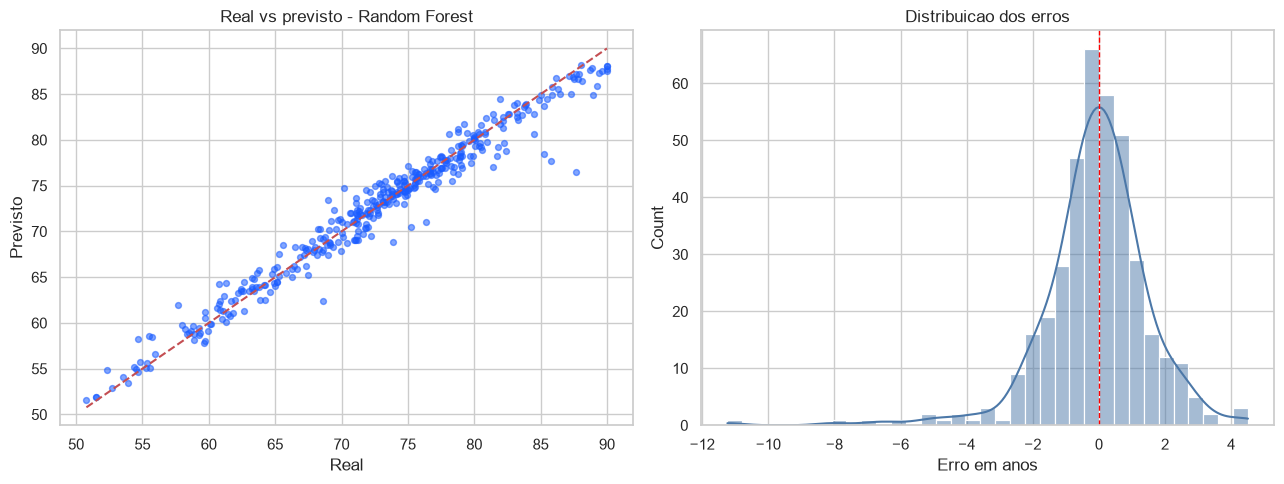

Erro absoluto por status:


,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
Developed,65.000,1.123,0.868,0.030,0.385,0.864,1.865,3.318
Developing,321.000,1.100,1.256,0.001,0.334,0.742,1.434,11.238


10 maiores erros absolutos no conjunto de teste:


,country,year,status,y_real,y_pred,error,abs_error
529,Egypt,2025,Developing,87.700,76.462,-11.238,11.238
527,Egypt,2023,Developing,85.760,77.698,-8.062,8.062
526,Egypt,2022,Developing,85.250,78.419,-6.831,6.831
1920,Zimbabwe,2016,Developing,68.630,62.374,-6.256,6.256
450,Democratic People's Republic of Korea,2016,Developing,76.330,71.009,-5.321,5.321
730,Honduras,2016,Developing,73.860,68.830,-5.030,5.030
1310,Paraguay,2016,Developing,75.220,70.434,-4.786,4.786
859,Jordan,2025,Developing,68.950,73.459,4.509,4.509
538,El Salvador,2024,Developing,70.210,74.706,4.496,4.496
1869,Uzbekistan,2025,Developing,81.450,77.049,-4.401,4.401


In [20]:
test_df = df_feat.loc[X_test.index, ["country", "year", "status", target_col]].copy()
test_df = test_df.rename(columns={target_col: "y_real"})
test_df["y_pred"] = best_y_pred
test_df["error"] = test_df["y_pred"] - test_df["y_real"]
test_df["abs_error"] = test_df["error"].abs()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(test_df["y_real"], test_df["y_pred"], alpha=0.55, s=18, color="#1A5CFF")
min_value = min(test_df["y_real"].min(), test_df["y_pred"].min())
max_value = max(test_df["y_real"].max(), test_df["y_pred"].max())
axes[0].plot([min_value, max_value], [min_value, max_value], "r--", linewidth=1.5)
axes[0].set_xlabel("Real")
axes[0].set_ylabel("Previsto")
axes[0].set_title(f"Real vs previsto - {best_model_name}")

sns.histplot(test_df["error"], bins=35, kde=True, color="#4C78A8", ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Distribuicao dos erros")
axes[1].set_xlabel("Erro em anos")

plt.tight_layout()
plt.show()

print("Erro absoluto por status:")
display(test_df.groupby("status")["abs_error"].describe())

print("10 maiores erros absolutos no conjunto de teste:")
display(test_df.sort_values("abs_error", ascending=False).head(10))

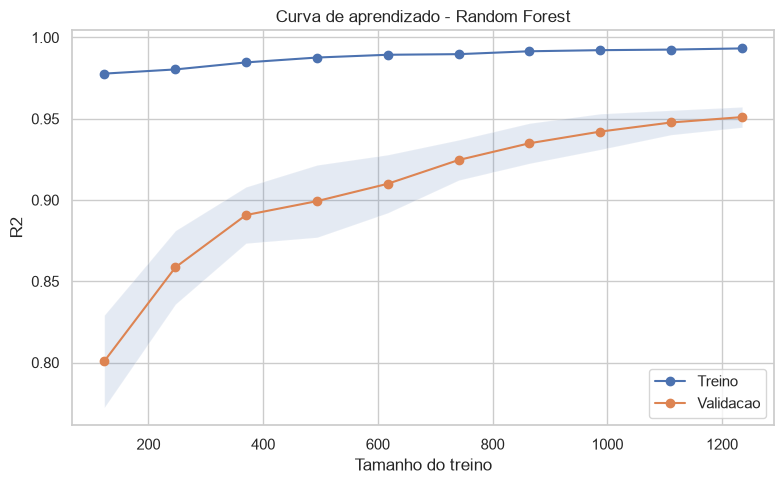

In [21]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Treino")
ax.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validacao")
ax.fill_between(
    train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1),
    alpha=0.15,
)
ax.set_title(f"Curva de aprendizado - {best_model_name}")
ax.set_xlabel("Tamanho do treino")
ax.set_ylabel("R2")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Previsao com Novos Dados

Simulamos um pais hipotetico de desenvolvimento medio em 2027. Depois calculamos intervalo de confianca por bootstrap e comparamos dois cenarios politicos:

- **Cenario A:** aumento de 20% nos gastos totais com saude.
- **Cenario B:** reducao de HIV/AIDS para 0.1.


In [22]:
novo_pais = pd.DataFrame([{
    "adult_mortality": 145,
    "log_gdp": np.log1p(4200),
    "schooling": 11.5,
    "income_composition_of_resources": 0.62,
    "vaccine_coverage_avg": 82.0,
    "hivaids": 0.4,
    "thinness_avg": 6.5,
    "status_enc": 0,
    "year_norm": (2027 - 2016) / 9,
    "total_expenditure": 6.1,
    "bmi": 24.5,
}])[selected_features]

pred_base = float(best_model.predict(novo_pais)[0])
print(f"Expectativa de vida prevista para o pais hipotetico em 2027: {pred_base:.2f} anos")

Expectativa de vida prevista para o pais hipotetico em 2027: 67.68 anos


In [23]:
N_BOOTSTRAP = 500
bootstrap_predictions = []

for i in range(N_BOOTSTRAP):
    X_bs, y_bs = resample(X_train, y_train, replace=True, random_state=42 + i)
    bootstrap_model = RandomForestRegressor(n_estimators=50, random_state=42 + i, n_jobs=-1)
    bootstrap_model.fit(X_bs, y_bs)
    bootstrap_predictions.append(float(bootstrap_model.predict(novo_pais)[0]))

ci_low, ci_high = np.percentile(bootstrap_predictions, [2.5, 97.5])
print(f"IC 95% por bootstrap: [{ci_low:.2f}, {ci_high:.2f}] anos")

IC 95% por bootstrap: [64.39, 70.94] anos


In [24]:
scenario_rows = []
base_row = novo_pais.iloc[0].copy()

scenarios = {
    "Base 2027": base_row.copy(),
    "A: +20% gastos em saude": base_row.copy(),
    "B: HIV/AIDS reduzido para 0.1": base_row.copy(),
    "A+B: gasto maior e HIV/AIDS 0.1": base_row.copy(),
}

scenarios["A: +20% gastos em saude"]["total_expenditure"] *= 1.20
scenarios["B: HIV/AIDS reduzido para 0.1"]["hivaids"] = 0.1
scenarios["A+B: gasto maior e HIV/AIDS 0.1"]["total_expenditure"] *= 1.20
scenarios["A+B: gasto maior e HIV/AIDS 0.1"]["hivaids"] = 0.1

scenario_df = pd.DataFrame(scenarios).T[selected_features]
scenario_df["pred_life_expectancy"] = best_model.predict(scenario_df[selected_features])
scenario_df["delta_vs_base"] = scenario_df["pred_life_expectancy"] - scenario_df.loc["Base 2027", "pred_life_expectancy"]

scenario_output = scenario_df[["pred_life_expectancy", "delta_vs_base", "total_expenditure", "hivaids"]].sort_values("pred_life_expectancy", ascending=False)
display(scenario_output)

best_policy = scenario_output.drop(index="Base 2027").sort_values("delta_vs_base", ascending=False).iloc[0]
print(
    "Recomendacao baseada no modelo: priorizar o cenario "
    f"'{best_policy.name}', com ganho estimado de {best_policy['delta_vs_base']:.2f} anos "
    "em relacao ao caso base."
)

,pred_life_expectancy,delta_vs_base,total_expenditure,hivaids
B: HIV/AIDS reduzido para 0.1,69.272,1.596,6.100,0.100
A+B: gasto maior e HIV/AIDS 0.1,69.183,1.507,7.320,0.100
A: +20% gastos em saude,67.726,0.050,7.320,0.400
Base 2027,67.676,0.000,6.100,0.400


Recomendacao baseada no modelo: priorizar o cenario 'B: HIV/AIDS reduzido para 0.1', com ganho estimado de 1.60 anos em relacao ao caso base.


## 9. Conclusoes Executivas

A celula final consolida os principais resultados quantitativos do notebook: melhor modelo, erro medio, fatores mais relevantes e recomendacao de politica publica baseada nos cenarios simulados.

In [25]:
summary = {
    "melhor_modelo": best_model_name,
    "test_r2": float(results_df.loc[0, "test_r2"]),
    "test_rmse_anos": float(results_df.loc[0, "test_rmse"]),
    "test_mae_anos": float(results_df.loc[0, "test_mae"]),
    "top_5_variaveis": feature_importance.head(5).index.tolist(),
    "predicao_base_2027": pred_base,
    "ic95_bootstrap": [float(ci_low), float(ci_high)],
}

print("Resumo executivo")
for key, value in summary.items():
    print(f"- {key}: {value}")

print("\nLeitura recomendada:")
print(
    "Os fatores mais influentes devem ser interpretados em conjunto com o conhecimento de saude publica. "
    "Variaveis como mortalidade adulta, escolaridade, renda, cobertura vacinal e HIV/AIDS tendem a capturar "
    "dimensoes estruturais distintas do desenvolvimento humano. O modelo apoia decisao, mas nao substitui "
    "avaliacao causal ou estudo de impacto de politicas."
)

Resumo executivo
- melhor_modelo: Random Forest
- test_r2: 0.9632879940231998
- test_rmse_anos: 1.6281576369378112
- test_mae_anos: 1.1041902849740899
- top_5_variaveis: ['hivaids', 'adult_mortality', 'schooling', 'thinness_avg', 'log_gdp']
- predicao_base_2027: 67.67580000000007
- ic95_bootstrap: [64.39288499999999, 70.936415]

Leitura recomendada:
Os fatores mais influentes devem ser interpretados em conjunto com o conhecimento de saude publica. Variaveis como mortalidade adulta, escolaridade, renda, cobertura vacinal e HIV/AIDS tendem a capturar dimensoes estruturais distintas do desenvolvimento humano. O modelo apoia decisao, mas nao substitui avaliacao causal ou estudo de impacto de politicas.
